In [1]:
import pandas as pd
import protfasta
import glob

# Gathering all inputs

## 1. SK Interpro evidence 1 and 2 sequences

In [2]:
def return_df(fasta_path):
    fasta_dict = protfasta.read_fasta(fasta_path, invalid_sequence_action='remove')
    return pd.DataFrame({'id' : fasta_dict.keys(), 'seq' : fasta_dict.values()})

In [3]:
sk_seqs = return_df("../output/interpro_uniprot_evid_1_2.fasta")
sk_seqs

,id,seq
0,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...
1,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...
2,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...
3,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...
4,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...
...,...,...
137431,tr|W8C846|W8C846_CERCA (Mediterranean fruit fl...,MNNITRLLANCTLNTTRCHLKYNAAALTAAIQLRGKCKVVVKPAPG...
137432,tr|W8CA25|W8CA25_CERCA (Mediterranean fruit fl...,MAGRPRRQAATRTAQIIEISDSEDDNSVSKNKRRRRDSSFSPPPTK...
137433,tr|W8QUS6|W8QUS6_MIMNO Cold shock domain prote...,MSDSEKQPEEKEEPKKNVIATKVTGTVKWFNVKSGYGFINRDDTKE...
137434,tr|X5CQH7|X5CQH7_9EUKA 30S plastidal ribosomal...,MSSARPLVLIASLLGASEALQSCHTRLVSSRVAATPRAAWALTMCD...


In [4]:
# sk_seqs = sk_seqs[(sk_seqs["seq"].str.len() >= 53) & (sk_seqs["seq"].str.len() < 1731)]
# sk_seqs

## 2. CL yeast orthologs

In [5]:
# Rerun September 25th, 2025
cl_paths = glob.glob("/global/scratch/projects/fc_mvslab/OpenProjects/Claire/transcription_factors/*/*.fasta")
cl_seqs = []
for cl_path in cl_paths:
    cl_seqs.append(return_df(cl_path))
cl_seqs = pd.concat(cl_seqs)
cl_seqs = cl_seqs.reset_index(drop = True)
cl_seqs

ValueError: No objects to concatenate

In [6]:
import numpy as np
np.percentile(cl_seqs["seq"].str.len(), 99)

TypeError: list indices must be integers or slices, not str

In [41]:
cl_seqs = cl_seqs.drop_duplicates(subset = "seq")
cl_seqs

,id,seq
0,g002981.m1_ashbya_aceri.final,MNRSDELQDAEDSGQQRYETYSCSRCRRLKKRCSKELPRCFSCEAA...
1,g001536.m1_brettanomyces_anomalus.final,MSDKPHNQYACTRCRRLKKKCSKEFPRCANCRKQNKVCEYVERKNK...
2,C1_01200W_A_candida_albicans.cgd,MRPIDSIVSKFRVQKHTSNLADNPAVLKHPEDMPKLTSCLRCRKLK...
3,g000106.m1_candida_albicans.final,MRPIDSIVSKFRVQKHTSNLADNPAVLKHPEDMPKLTSCLRCRKLK...
4,g001050.m1_candida_dubliniensis.final,MRPTDSIVSKFRVQKPTSNLANNPAVLRHPENMPKLTSCLRCRKLK...
...,...,...
181064,g003574.m1_yHMPu5000037837_Vanderwaltozyma_ver...,MDTTNSLFDSINTITTTNLSTSSTTTDNVKDFNNLFDDDFDLGIDF...
181065,g000938.m1_yHMPu5000040961_kazachstania_turice...,MQHHNMELDNLFDLDADIDFETAYQLFSNLDNIQEKNIDIFTQNVH...
181066,g003697.m1_yHMPu5000040963_lachancea_quebecuen...,MDTDRLLDIFDFDLEIDFETAYEMINKEDQNAKHATERSLVENEVD...
181067,g004154.m1_yHQL494_Lachancea_sp_nov_plate34_PL...,MENEHLLDVFDYDLDIDFETAYEMINNEDQVFKGNNENHMAIDPEV...


In [42]:
cl_seqs[(cl_seqs["seq"].str.len()<53)]

,id,seq
5654,g011087.m1_yHMPu5000035263_Candida_solani_SPAD...,SSFLRIWVSENAQNYQILNAKKPDAYKFKLIQFFININLSINYGLV...
24432,g000758.m1_yHMPu5000035663_Meyerozyma_guillier...,MSAANPMILTGDSFESADVFNSASATSDRTLGSQMLAMKASENSEE...
30135,g001009.m1_yHMPu5000040795_metschnikowia_matae...,PILEDLNDYMNLYEKEFNECLLPVHSYANSQTLRNPMIDNFENIPSFH
46652,g000838.m1_yHMPu5000037895_candida_jaroonii_18...,MDEYDNSEVNNEEEYDRLLLLSLILQINLDSCFSVYENFDLIFAIGDHM
48910,g000779.m1_yHMPu5000038063_candida_xylanilytic...,MNFEPTDYIQHLNLDLDSVVSPTMTQQQLDHELDLFSQANDFFSLDVLG
56026,g001649.m1_yHMPu5000035711_botryozyma_cognata_...,MSYSSKGEYSNNNTNVNGFTQFYNPNSTFSSYNDSTEAYPDSLSRSMRP
60237,g002839.m1_yHMPu5000040949_metschnikowia_hawai...,QPTKWEFRHSATQIRKGDVDSLSLIKRKSSKIFNSPKEIVYLKPLP...
69900,g004941.m1_yHMPu5000037226_ogataea_haglerorum_...,LQEQKLKALRQEKPSTATPPPPGLFPATGADSIKTNSAELLSQLMG...
74232,g012362.m1_yHMPu5000038388_candida_inconspicua...,EIKLYNESKEALQHAHDVQQMAEMVNMVDMEGLEGIELPPKKKSKKSKK
75774,g000265.m1_yHMPu5000034950_citeromyces_hawaiie...,PDWESYDFTKLDPSSPEDKEFVNDMWAWDKPVIVNGESREIADGKVLK


In [43]:
cl_seqs[(cl_seqs["seq"].str.len() > 1891)]

,id,seq
550,g006213.m1_yHMPu5000035688_Cyberlindnera_xylos...,MKLHLFALLWSLWLFSLVSAQDNEDETEPWIEGAFVENVPTWYIHI...
8001,g000481.m1_yHMPu5000041819_magnusiomyces_starm...,MSSGNAPFISPVSSVDTPYNLPNQRQQQELPPNNYQQQYTFFSPNQ...
8316,g005008.m1_yHKB357_New_Genus_SPADES.final,LVNSAGSTIVVVEVPDLSTTTSPGPVSETTTFTLVNSAGSSIVVVE...
23489,g006333.m1_yHMPu5000041796_saccharomycopsis_fi...,MSYHRDSNSNKNETIDNDNDNDNQRDNLIPVQQHGHDQGQHTLEEL...
29037,g000223.m1_saprochaete_ingens.final,MNTQQQQQQHPPPQGPPGIPAQVQPQNSSRGGIASNNPGTQQQQQQ...
...,...,...
149245,g002499.m1_yHMPu5000034628_pichia_fermentans_1...,MDFQITREAPTRGLCRAQLTKEGRILFQTRNGLMMYDTNTGFRGKT...
156264,g000315.m1_yHMPu5000035696_hanseniaspora_singu...,MPQPTLNNTALVIQETGYSYEKHVDDFRNIMTKLLYECSNIFKQHL...
164236,g004370.m1_hanseniaspora_gamundiae.final,MSQSMTPSVSTPATSTAATFSKLQSCDRCRLKKIKCSFSSDKALNG...
164929,g002830.m1_yHMPu5000035684_kloeckera_hatyaiens...,MANSDKAKKEQQYQSCDRCRSKKIKCTYDKKSLKQCINCKNAFLEC...


In [44]:
# Overwriting earlier file
protfasta.write_fasta(dict(zip(cl_seqs["id"], cl_seqs["seq"])), "../output/cl_seqs.fasta")

In [45]:
cl_seqs = return_df("../output/cl_seqs.fasta")
cl_seqs

,id,seq
0,g002981.m1_ashbya_aceri.final,MNRSDELQDAEDSGQQRYETYSCSRCRRLKKRCSKELPRCFSCEAA...
1,g001536.m1_brettanomyces_anomalus.final,MSDKPHNQYACTRCRRLKKKCSKEFPRCANCRKQNKVCEYVERKNK...
2,C1_01200W_A_candida_albicans.cgd,MRPIDSIVSKFRVQKHTSNLADNPAVLKHPEDMPKLTSCLRCRKLK...
3,g000106.m1_candida_albicans.final,MRPIDSIVSKFRVQKHTSNLADNPAVLKHPEDMPKLTSCLRCRKLK...
4,g001050.m1_candida_dubliniensis.final,MRPTDSIVSKFRVQKPTSNLANNPAVLRHPENMPKLTSCLRCRKLK...
...,...,...
172849,g003574.m1_yHMPu5000037837_Vanderwaltozyma_ver...,MDTTNSLFDSINTITTTNLSTSSTTTDNVKDFNNLFDDDFDLGIDF...
172850,g000938.m1_yHMPu5000040961_kazachstania_turice...,MQHHNMELDNLFDLDADIDFETAYQLFSNLDNIQEKNIDIFTQNVH...
172851,g003697.m1_yHMPu5000040963_lachancea_quebecuen...,MDTDRLLDIFDFDLEIDFETAYEMINKEDQNAKHATERSLVENEVD...
172852,g004154.m1_yHQL494_Lachancea_sp_nov_plate34_PL...,MENEHLLDVFDYDLDIDFETAYEMINNEDQVFKGNNENHMAIDPEV...


In [30]:
# cl_seqs = cl_seqs[(cl_seqs["seq"].str.len() >= 53) & (cl_seqs["seq"].str.len() < 1731)]
# cl_seqs

# 3. Plant species

In [48]:
plant_seqs = return_df("../data/PlantTFDB-all_TF_pep.fas")
plant_seqs

,id,seq
0,KFK36254.1 Arabis alpina|G2-like|G2-like famil...,MYSAIRSLPVDGSMGEYSDGTNLPIEACLVLTTDPKPRLRWTTELH...
1,KFK25038.1 Arabis alpina|GeBP|GeBP family protein,MAPKHTDTIQNPPMPSSSSEEESASSGEDSDSSKKHNSASDSDPIK...
2,KFK35037.1 Arabis alpina|bZIP|bZIP family protein,MTTTTTPHWPDFSSQKLPSIAATAAATAATAGQNQQNQNPSWMDEF...
3,KFK44643.1 Arabis alpina|ERF|ERF family protein,MEGERHDSTTSSSRKRSHEPAEERPASHVATMAFKEKPYRGIRMRK...
4,KFK32619.1 Arabis alpina|B3|B3 family protein,MAKPPQFFHTLVNTHLVIPKDFFSKYIQGKSVDDTVELKSDSTDIN...
...,...,...
310651,Zpz_sc00227.1.g00450.1.am.mk Zoysia pacifica|b...,MYGSTVSKDLNLPAVQPQPATGARTPPPQMSSSGLLRYRSAPSNLL...
310652,Zpz_sc01778.1.g00020.1.am.mk Zoysia pacifica|M...,MARKPNQHAAAGTGAAAEEKKERRGLWSPEEDERLFTQITCHGVST...
310653,Zpz_sc01095.1.g00030.1.sm.mk Zoysia pacifica|H...,MEGSQSRSGGGSSSPPPFLIKTYEMVEDPATNRVVSWGPGGASFVV...
310654,Zpz_sc05215.1.g00010.1.am.mk Zoysia pacifica|b...,MSDDSDKQRQCRRGVGVHELDAAMALADLAGVSPEPQKLHLQPAAA...


##  Both together now

In [49]:
all_seqs = pd.concat([sk_seqs, cl_seqs, plant_seqs])
all_seqs

,id,seq
0,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...
1,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...
2,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...
3,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...
4,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...
...,...,...
310651,Zpz_sc00227.1.g00450.1.am.mk Zoysia pacifica|b...,MYGSTVSKDLNLPAVQPQPATGARTPPPQMSSSGLLRYRSAPSNLL...
310652,Zpz_sc01778.1.g00020.1.am.mk Zoysia pacifica|M...,MARKPNQHAAAGTGAAAEEKKERRGLWSPEEDERLFTQITCHGVST...
310653,Zpz_sc01095.1.g00030.1.sm.mk Zoysia pacifica|H...,MEGSQSRSGGGSSSPPPFLIKTYEMVEDPATNRVVSWGPGGASFVV...
310654,Zpz_sc05215.1.g00010.1.am.mk Zoysia pacifica|b...,MSDDSDKQRQCRRGVGVHELDAAMALADLAGVSPEPQKLHLQPAAA...


In [50]:
# Dropping duplicate sequences
all_seqs = all_seqs.drop_duplicates(subset = "seq")
all_seqs

,id,seq
0,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...
1,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...
2,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...
3,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...
4,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...
...,...,...
310651,Zpz_sc00227.1.g00450.1.am.mk Zoysia pacifica|b...,MYGSTVSKDLNLPAVQPQPATGARTPPPQMSSSGLLRYRSAPSNLL...
310652,Zpz_sc01778.1.g00020.1.am.mk Zoysia pacifica|M...,MARKPNQHAAAGTGAAAEEKKERRGLWSPEEDERLFTQITCHGVST...
310653,Zpz_sc01095.1.g00030.1.sm.mk Zoysia pacifica|H...,MEGSQSRSGGGSSSPPPFLIKTYEMVEDPATNRVVSWGPGGASFVV...
310654,Zpz_sc05215.1.g00010.1.am.mk Zoysia pacifica|b...,MSDDSDKQRQCRRGVGVHELDAAMALADLAGVSPEPQKLHLQPAAA...


In [53]:
np.percentile(all_seqs["seq"].str.len(), 99)

1442.0

In [54]:
all_seqs = all_seqs[(all_seqs["seq"].str.len() <= 1442.0) & (all_seqs["seq"].str.len() >= 53)]
all_seqs

,id,seq
0,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...
1,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...
2,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...
3,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...
4,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...
...,...,...
310651,Zpz_sc00227.1.g00450.1.am.mk Zoysia pacifica|b...,MYGSTVSKDLNLPAVQPQPATGARTPPPQMSSSGLLRYRSAPSNLL...
310652,Zpz_sc01778.1.g00020.1.am.mk Zoysia pacifica|M...,MARKPNQHAAAGTGAAAEEKKERRGLWSPEEDERLFTQITCHGVST...
310653,Zpz_sc01095.1.g00030.1.sm.mk Zoysia pacifica|H...,MEGSQSRSGGGSSSPPPFLIKTYEMVEDPATNRVVSWGPGGASFVV...
310654,Zpz_sc05215.1.g00010.1.am.mk Zoysia pacifica|b...,MSDDSDKQRQCRRGVGVHELDAAMALADLAGVSPEPQKLHLQPAAA...


In [55]:
protfasta.write_fasta(dict(zip(all_seqs["id"], all_seqs["seq"])), "../data/CL_SK_plant_input.fasta")

# Remove seqences with low disorder

In [60]:
CL_SK_plant_seq_props = pd.read_csv("../output/CL_SK_plant_seq_props.csv")
CL_SK_plant_seq_props

,id,seq,net charge,hydrophobics_prop,percent_disorder
0,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,-9,0.106472,69.311
1,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,-14,0.109804,63.922
2,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...,6,0.128668,67.494
3,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...,10,0.162011,52.793
4,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,-26,0.118033,68.033
...,...,...,...,...,...
576611,Zpz_sc00227.1.g00450.1.am.mk Zoysia pacifica|b...,MYGSTVSKDLNLPAVQPQPATGARTPPPQMSSSGLLRYRSAPSNLL...,11,0.122807,72.515
576612,Zpz_sc01778.1.g00020.1.am.mk Zoysia pacifica|M...,MARKPNQHAAAGTGAAAEEKKERRGLWSPEEDERLFTQITCHGVST...,-3,0.150235,30.516
576613,Zpz_sc01095.1.g00030.1.sm.mk Zoysia pacifica|H...,MEGSQSRSGGGSSSPPPFLIKTYEMVEDPATNRVVSWGPGGASFVV...,-23,0.151927,58.050
576614,Zpz_sc05215.1.g00010.1.am.mk Zoysia pacifica|b...,MSDDSDKQRQCRRGVGVHELDAAMALADLAGVSPEPQKLHLQPAAA...,4,0.112450,81.124


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


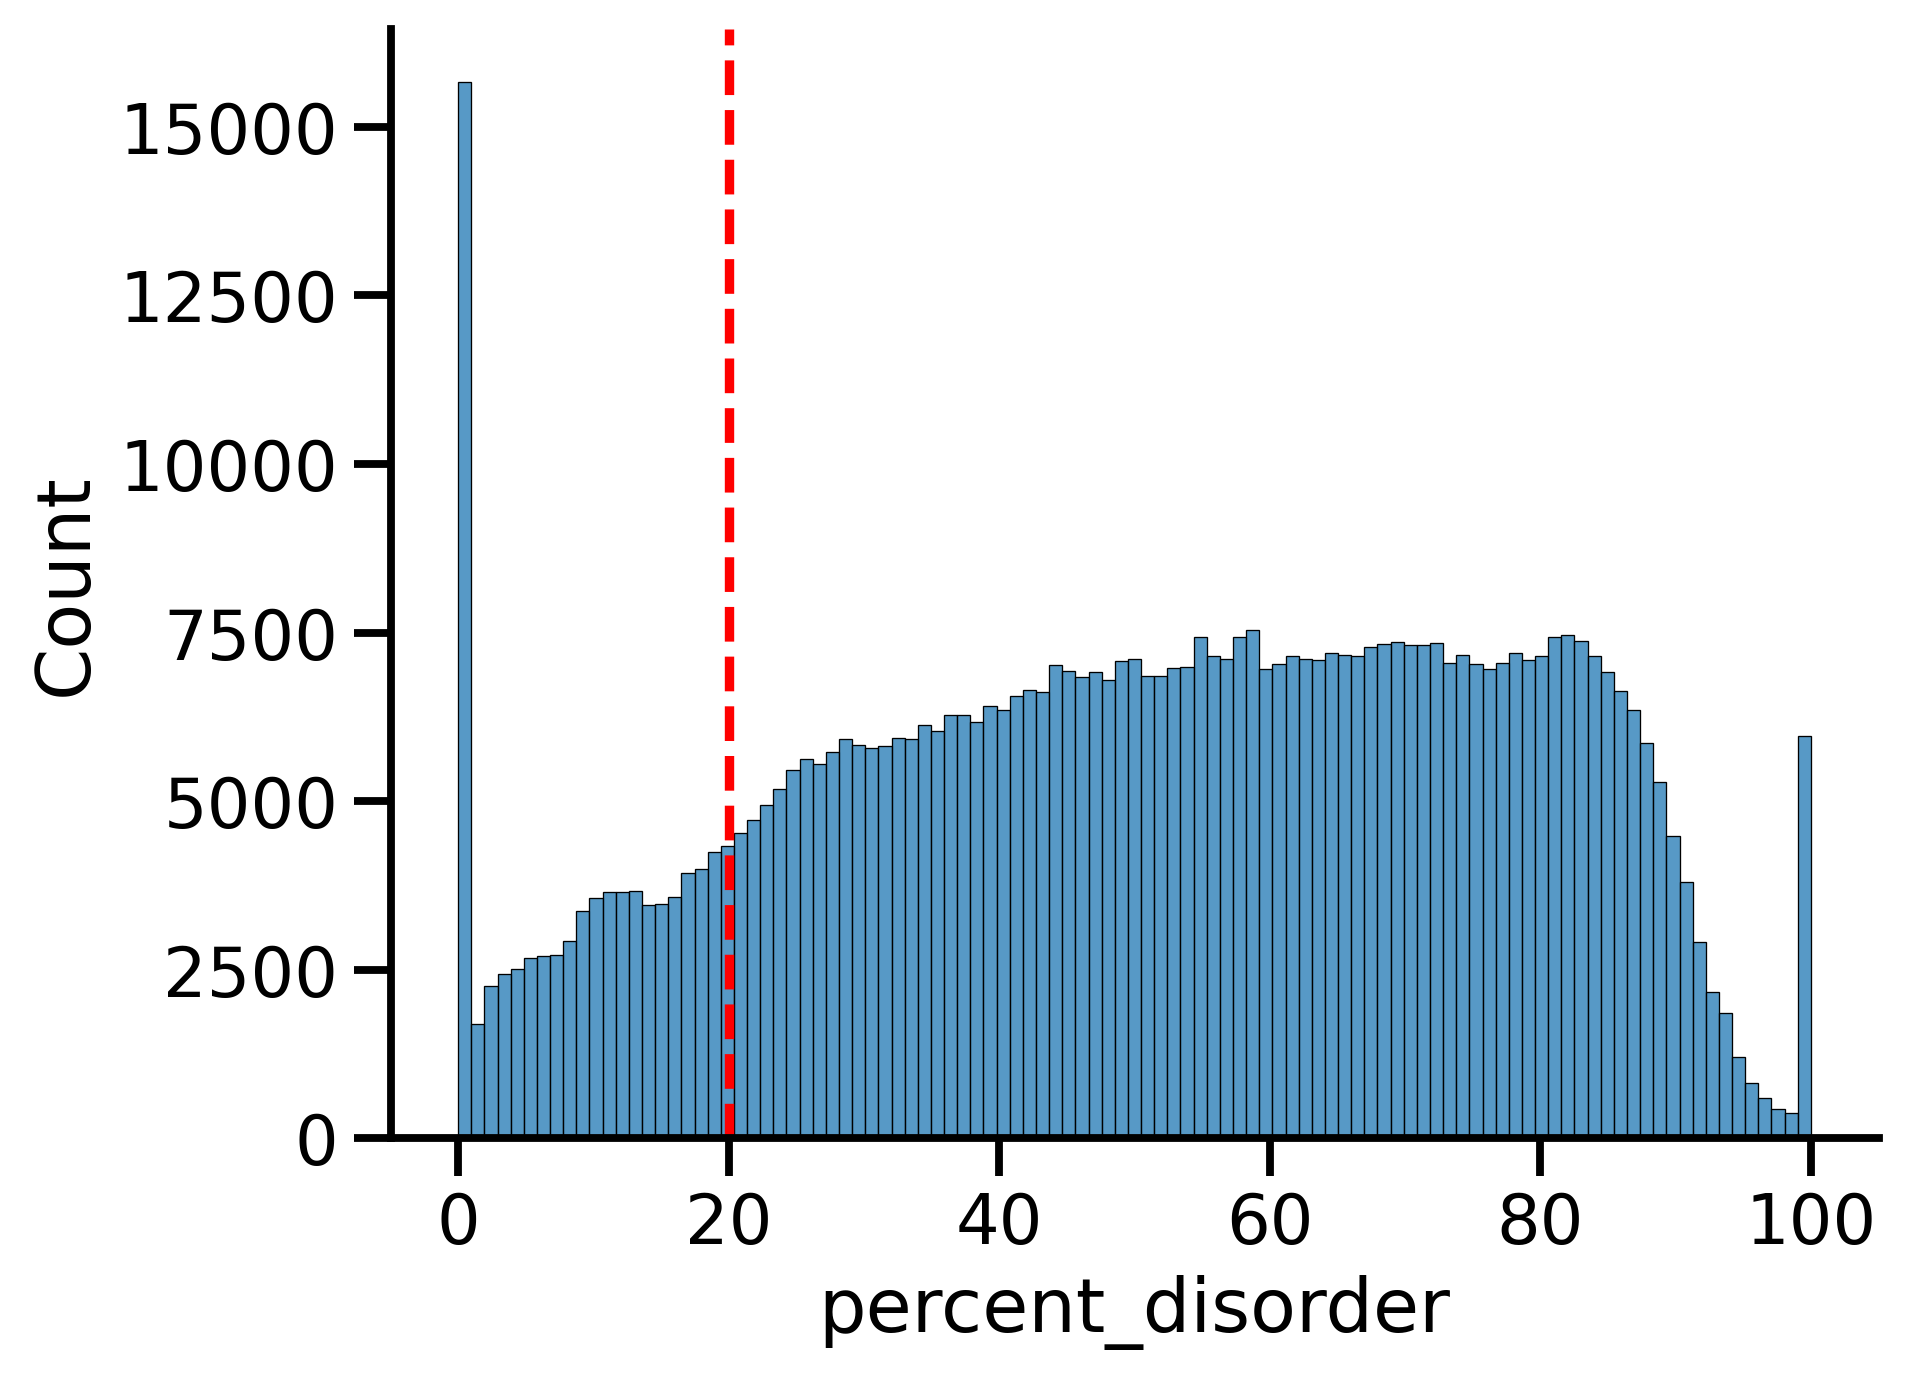

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context('talk')
plt.figure(dpi = 300)
sns.histplot(CL_SK_plant_seq_props["percent_disorder"])
plt.axvline(20, color = 'red', linestyle = 'dashed')
sns.despine()

In [72]:
CL_SK_plant_seqs_disord_thresh = CL_SK_plant_seq_props[CL_SK_plant_seq_props["percent_disorder"] >= 20][["id", "seq"]]
CL_SK_plant_seqs_disord_thresh

,id,seq
0,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...
1,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...
2,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...
3,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...
4,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...
...,...,...
576611,Zpz_sc00227.1.g00450.1.am.mk Zoysia pacifica|b...,MYGSTVSKDLNLPAVQPQPATGARTPPPQMSSSGLLRYRSAPSNLL...
576612,Zpz_sc01778.1.g00020.1.am.mk Zoysia pacifica|M...,MARKPNQHAAAGTGAAAEEKKERRGLWSPEEDERLFTQITCHGVST...
576613,Zpz_sc01095.1.g00030.1.sm.mk Zoysia pacifica|H...,MEGSQSRSGGGSSSPPPFLIKTYEMVEDPATNRVVSWGPGGASFVV...
576614,Zpz_sc05215.1.g00010.1.am.mk Zoysia pacifica|b...,MSDDSDKQRQCRRGVGVHELDAAMALADLAGVSPEPQKLHLQPAAA...


In [73]:
protfasta.write_fasta(dict(zip(CL_SK_plant_seqs_disord_thresh["id"], CL_SK_plant_seqs_disord_thresh["seq"])), "../data/CL_SK_plant_seqs_disord_thresh.fasta")

In [16]:
# ! cp ../data/CL_SK_input.fasta ../output/CL_SK_input.fasta

# Running mmseqs2
Generating commands (run from mmseqs folder of output)

In [3]:
def db_name(fasta_path, prefix):
    print(f"mmseqs createdb {fasta_path} {prefix}_DB")
    print(f"mmseqs cluster {prefix}_DB {prefix}_DB_clu {prefix}tmp")                      
    print(f"mmseqs createtsv {prefix}_DB {prefix}_DB {prefix}_DB_clu {prefix}_DB_clu.tsv")


In [4]:
db_name("../interpro_uniprot_evid_1_2.fasta", "SK")

mmseqs createdb ../interpro_uniprot_evid_1_2.fasta SK_DB
mmseqs cluster SK_DB SK_DB_clu SKtmp
mmseqs createtsv SK_DB SK_DB SK_DB_clu SK_DB_clu.tsv


In [5]:
db_name("../cl_seqs.fasta", "CL")

mmseqs createdb ../cl_seqs.fasta CL_DB
mmseqs cluster CL_DB CL_DB_clu CLtmp
mmseqs createtsv CL_DB CL_DB CL_DB_clu CL_DB_clu.tsv


In [6]:
db_name("../CL_SK_input.fasta", "CL_SK")

mmseqs createdb ../CL_SK_input.fasta CL_SK_DB
mmseqs cluster CL_SK_DB CL_SK_DB_clu CL_SKtmp
mmseqs createtsv CL_SK_DB CL_SK_DB CL_SK_DB_clu CL_SK_DB_clu.tsv


## 1. SK seqs alone

In [29]:
SK_clusters = pd.read_csv("../output/mmseqs/SK_DB_clu.tsv", sep = "\t", header = None)
SK_clusters[0].value_counts()[:20]

0
A0A2J8IQ41    1933
A6NDX5        1392
A0A671UR79    1319
A0A6J0CWZ7    1190
A0A6P6H4V7    1134
A0A7J8CNN2    1118
Q9SEG4        1014
B5BPD7         958
A0AAV2MB89     955
H3BZE7         808
A0A5F8HG07     777
A0A8D1MTT0     763
A0A8C0DKP6     746
A0A2J8J2W2     706
Q8KND2         703
A0A7L1XQA3     634
A0A8I5ZUC5     631
A0A8B8Z672     619
A0A833YR08     548
Q3B799         513
Name: count, dtype: int64

# 2. CL seqs alone

In [ ]:
CL_clusters = pd.read_csv("../output/mmseqs/CL_DB_clu.tsv", sep = "\t", header = None)
CL_clusters[0].value_counts()[:20]

0
g002549.m1_yHMPu5000034659_debaryomyces_hansenii_180604.final                   1681
g000152.m1_yHMPu5000037206_wickerhamiella_kurtzmanii_210210.final               1451
g000476.m1_yHMPu5000038408_candida_borneonana_170713.final                      1419
g002714.m1_yHMPu5000034974_deakozyma_indianensis_160519.final                   1211
g004041.m1_yHMPu5000026150_trichomonascus_petasosporus_180604.final             1088
g005224.m1_yHMPu5000035332_candida_insectalens_201018.final                      904
g000951.m1_yHMPu5000038317_tortispora_sangerardonensis_170713.final              842
g003254.m1_yHMPu5000038368_candida_pseudoflosculorum_170713.final                827
g003617.m1_yHMPu5000041848_candida_musae_170713.final                            778
g000143.m1_spathaspora_xylofermentans.final                                      770
g001633.m1_yHMPu5000035327_candida_fluviatilis_190924.final                      699
g004450.m1_yHMPu5000037899_candida_koratica_180604.final       

In [31]:
CL_biggest_cluster = CL_clusters[CL_clusters[0] == "g002549.m1_yHMPu5000034659_debaryomyces_hansenii_180604.final"]
CL_biggest_cluster = CL_biggest_cluster.rename(columns = {1 : "id"})
CL_biggest_cluster

,0,id
76460,g002549.m1_yHMPu5000034659_debaryomyces_hansen...,g002549.m1_yHMPu5000034659_debaryomyces_hansen...
76461,g002549.m1_yHMPu5000034659_debaryomyces_hansen...,g000463.m1_yHMPu5000041829_debaryomyces_fabryi...
76462,g002549.m1_yHMPu5000034659_debaryomyces_hansen...,g002533.m1_yHMPu5000041824_debaryomyces_subglo...
76463,g002549.m1_yHMPu5000034659_debaryomyces_hansen...,g002266.m1_yHMPu5000034756_hemisphaericaspora_...
76464,g002549.m1_yHMPu5000034659_debaryomyces_hansen...,g005746.m1_yHMPu5000038063_candida_xylanilytic...
...,...,...
78136,g002549.m1_yHMPu5000034659_debaryomyces_hansen...,g003990.m1_yHMPu5000035014_candida_atakaporum_...
78137,g002549.m1_yHMPu5000034659_debaryomyces_hansen...,g004186.m1_yHMPu5000035021_candida_choctaworum...
78138,g002549.m1_yHMPu5000034659_debaryomyces_hansen...,g004774.m1_yHMPu5000035023_candida_guaymorum_1...
78139,g002549.m1_yHMPu5000034659_debaryomyces_hansen...,g004543.m1_spathaspora_boniae.final


In [35]:
CL_biggest_cluster_seqs = pd.merge(cl_seqs, CL_biggest_cluster, on = "id")
CL_biggest_cluster_seqs

,id,seq,0
0,g002841.m1_candida_albicans.final,MSIATTPIETPKSPKSTEPQVRKRKKVSTVCTNCRKRKIRCDRQHP...,g002549.m1_yHMPu5000034659_debaryomyces_hansen...
1,g004882.m1_candida_albicans.final,MGQKRNRISKVCDFCKRRKVKCDLGNPCSMCVKYKKSPCVYSEQPT...,g002549.m1_yHMPu5000034659_debaryomyces_hansen...
2,g001177.m1_candida_auris.final,MNGFYNNTRPQIKKSRSVSSKLITSPDQDGVSLNHQDNRNGSMSTP...,g002549.m1_yHMPu5000034659_debaryomyces_hansen...
3,g001710.m1_candida_auris.final,MNPVPRKRKRISIVCNICKARKVRCDRNTPCNLCIRHRTAHLCAYT...,g002549.m1_yHMPu5000034659_debaryomyces_hansen...
4,g005359.m1_candida_auris.final,MVQDIQNQPPGSSKKRMRITLSCDQCRKRKVKCDRKYPCSTCAQHG...,g002549.m1_yHMPu5000034659_debaryomyces_hansen...
...,...,...,...
1676,g001450.m1_yHRVM31_Schwanniomyces_sp_nov_plate...,MNTGTIKKRNRISLSCNLCKKRKVKCDRHHPCSACIKTNIPDQCKY...,g002549.m1_yHMPu5000034659_debaryomyces_hansen...
1677,g001605.m1_yHRVM31_Schwanniomyces_sp_nov_plate...,MLSRKRKRATKVCDFCKRRKVKCDRGSPCSSCVKYNNRNCHYEEVT...,g002549.m1_yHMPu5000034659_debaryomyces_hansen...
1678,g003508.m1_yHRVM31_Schwanniomyces_sp_nov_plate...,MENIVRKRMRSTKVCDFCKRRKVKCDRESPCSTCIQYNNRNCHYEE...,g002549.m1_yHMPu5000034659_debaryomyces_hansen...
1679,g004796.m1_yHRVM31_Schwanniomyces_sp_nov_plate...,MSSIIKRKRPRLTCKQCSERKVKCDKRRPCSSCLKVSLGHVCTYDE...,g002549.m1_yHMPu5000034659_debaryomyces_hansen...


In [37]:
protfasta.write_fasta(dict(zip(CL_biggest_cluster_seqs["id"], CL_biggest_cluster_seqs["seq"])), "../output/CL_biggest_cluster.fasta")

In [46]:
CL_clusters[0].value_counts().sort_values(ascending=True)[1500:6000]

0
g002245.m1_yHMPu5000035043_babjeviella_inositovora_180604.final                                1
g010421.m1_yHMPu5000035263_Candida_solani_SPADES.final                                         1
g002142.m1_yHMPu5000037237_sugiyamaella_mastotermitis_210305.final                             1
g000501.m1_yHMPu5000037923_ascoidea_tarda_180604.final                                         1
g005218.m1_yHAB150_kazachstania_exigua_160519.final                                            1
                                                                                              ..
g004875.m1_yHMPu5000035242_zygoascus_ofunaensis_160928.final                                   2
g004480.m1_yHMPu5000035650_trigonopsis_variabilis_160613.final                                 2
g004179.m1_clavispora_lusitaniae.final                                                         2
g004463.m1_yHMPu5000034862_zygotorulaspora_florentina_160519.final                             2
g004434.m1_yHMPu5000035694_h

In [47]:
CL_two_cluster = CL_clusters[CL_clusters[0] == "g004875.m1_yHMPu5000035242_zygoascus_ofunaensis_160928.final"]
CL_two_cluster = CL_two_cluster.rename(columns = {1 : "id"})
CL_two_cluster

,0,id
103152,g004875.m1_yHMPu5000035242_zygoascus_ofunaensi...,g004875.m1_yHMPu5000035242_zygoascus_ofunaensi...
103153,g004875.m1_yHMPu5000035242_zygoascus_ofunaensi...,g002403.m1_yHMPu5000040906_zygoascus_tannicolu...


In [48]:
CL_two_cluster_seqs = pd.merge(cl_seqs, CL_two_cluster, on = "id")
CL_two_cluster_seqs

,id,seq,0
0,g004875.m1_yHMPu5000035242_zygoascus_ofunaensi...,MEIDDDQRRIEEDLRDPMQSSPVNEEELEVSRLINIIQQENQNHQS...,g004875.m1_yHMPu5000035242_zygoascus_ofunaensi...
1,g002403.m1_yHMPu5000040906_zygoascus_tannicolu...,MEIDDDESQIQENLHHSLHSDSVNEDELEVSRLIDIIQQENQSHQS...,g004875.m1_yHMPu5000035242_zygoascus_ofunaensi...


In [49]:
protfasta.write_fasta(dict(zip(CL_two_cluster_seqs["id"], CL_two_cluster_seqs["seq"])), "../output/CL_two_cluster_seqs.fasta")

In [53]:
CL_cluster_counts = pd.DataFrame(CL_clusters[0].value_counts()).reset_index()
CL_cluster_counts

,0,count
0,g002549.m1_yHMPu5000034659_debaryomyces_hansen...,1681
1,g000152.m1_yHMPu5000037206_wickerhamiella_kurt...,1451
2,g000476.m1_yHMPu5000038408_candida_borneonana_...,1419
3,g002714.m1_yHMPu5000034974_deakozyma_indianens...,1211
4,g004041.m1_yHMPu5000026150_trichomonascus_peta...,1088
...,...,...
9698,g000638.m1_yHMPu5000037241_starmerella_scaraba...,1
9699,g001208.m1_yHMPu5000037223_hyphopichia_buzzini...,1
9700,g014476.m1_yHMPu5000035263_Candida_solani_SPAD...,1
9701,g006820.m1_yHMPu5000034760_lipomyces_kononenko...,1


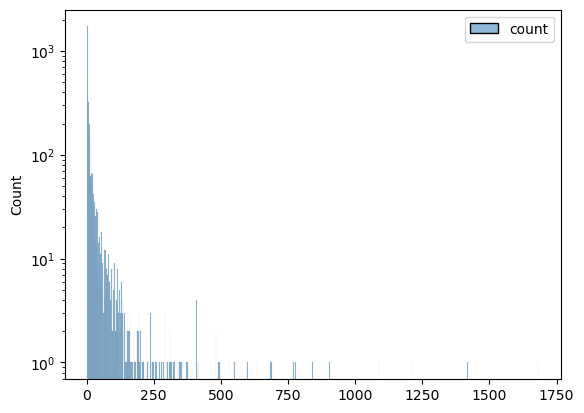

In [56]:
import seaborn as sns
ax = sns.histplot(CL_cluster_counts[CL_cluster_counts["count"] > 1])
ax.set_yscale('log')

<Axes: xlabel='count', ylabel='Count'>

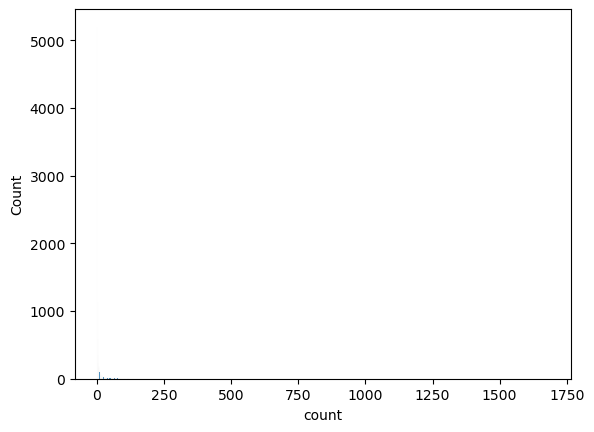

In [24]:
sns.histplot(CL_clusters[0].value_counts())

# 3. SK + CL seqs

In [20]:
CL_SK_clusters = pd.read_csv("../output/mmseqs/CL_SK_DB_clu.tsv", sep = "\t", header = None)
CL_SK_clusters[0].value_counts()

0
g003742.m1_yHMPu5000041841_debaryomyces_coudertii_170713.final                       1986
A0A8C9UIW4                                                                           1881
F7DCB7                                                                               1449
g004583.m1_yHMPu5000037203_Pichia_nanzhaoensis_SPADES.final                          1447
A6NDX5                                                                               1440
                                                                                     ... 
g002621.m1_yHMPu5000034697_lachancea_dasiensis_190924.final                             1
g017338.m1_yHMPu5000034630_Magnusiomyces_magnusii_S134_MASURCA.haplomerger2.final       1
g001035.m1_yHMPu5000038395_candida_danieliae_170713.final                               1
g001666.m1_yHMPu5000038091_candida_pseudolambica_201018.final                           1
g009675.m1_yHQL14_Wickerhamomyces_sp_nov_plate33_MASURCA.final                          1
Name: co

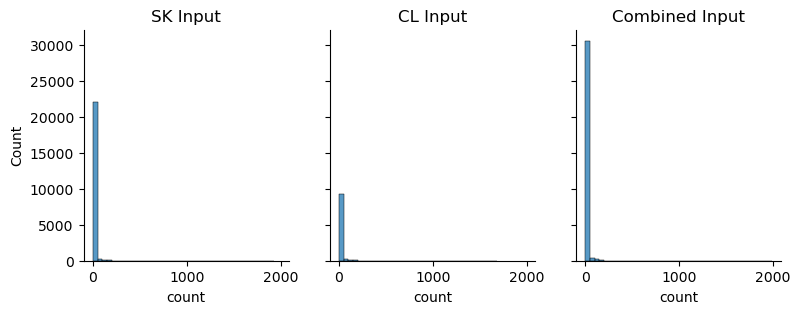

In [37]:
fig, axs = plt.subplots(1, 3, figsize = (9,3), sharex = True, sharey = True)

sns.histplot(SK_clusters[0].value_counts(), binwidth = 50, ax=axs[0])
sns.histplot(CL_clusters[0].value_counts(), binwidth = 50, ax=axs[1])
sns.histplot(CL_SK_clusters[0].value_counts(), binwidth = 50, ax=axs[2])

axs[0].set_title('SK Input')
axs[1].set_title('CL Input')
axs[2].set_title('Combined Input')

sns.despine()
# plt.xlabel("Cluster Size")
# plt.title("SK Training")

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_cluster_size(cluster_df, ax):
    plot_ready = pd.DataFrame(cluster_df[0].value_counts()).reset_index().reset_index()
    sns.lineplot(data = plot_ready, x= "index", y = "count", ax=ax)
    ax.set_xlabel("Cluster Size Rank Order") 
    ax.set_ylabel("Cluster Size")
    sns.despine()

Text(0.02, 0.5, 'Cluster Size')

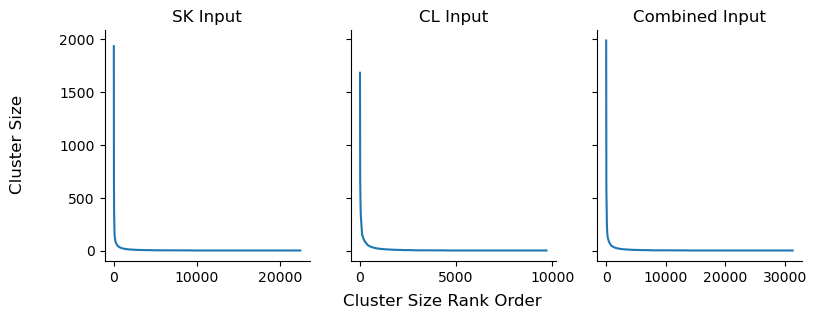

In [22]:
fig, axs = plt.subplots(1, 3, sharey = True, figsize = (9,3))
plot_cluster_size(SK_clusters, axs[0])
axs[0].set_title('SK Input')
plot_cluster_size(CL_clusters, axs[1])
axs[1].set_title('CL Input')
plot_cluster_size(CL_SK_clusters, axs[2])
axs[2].set_title('Combined Input')

for ax in axs:
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.supxlabel("Cluster Size Rank Order", y = -0.05)
fig.supylabel("Cluster Size")


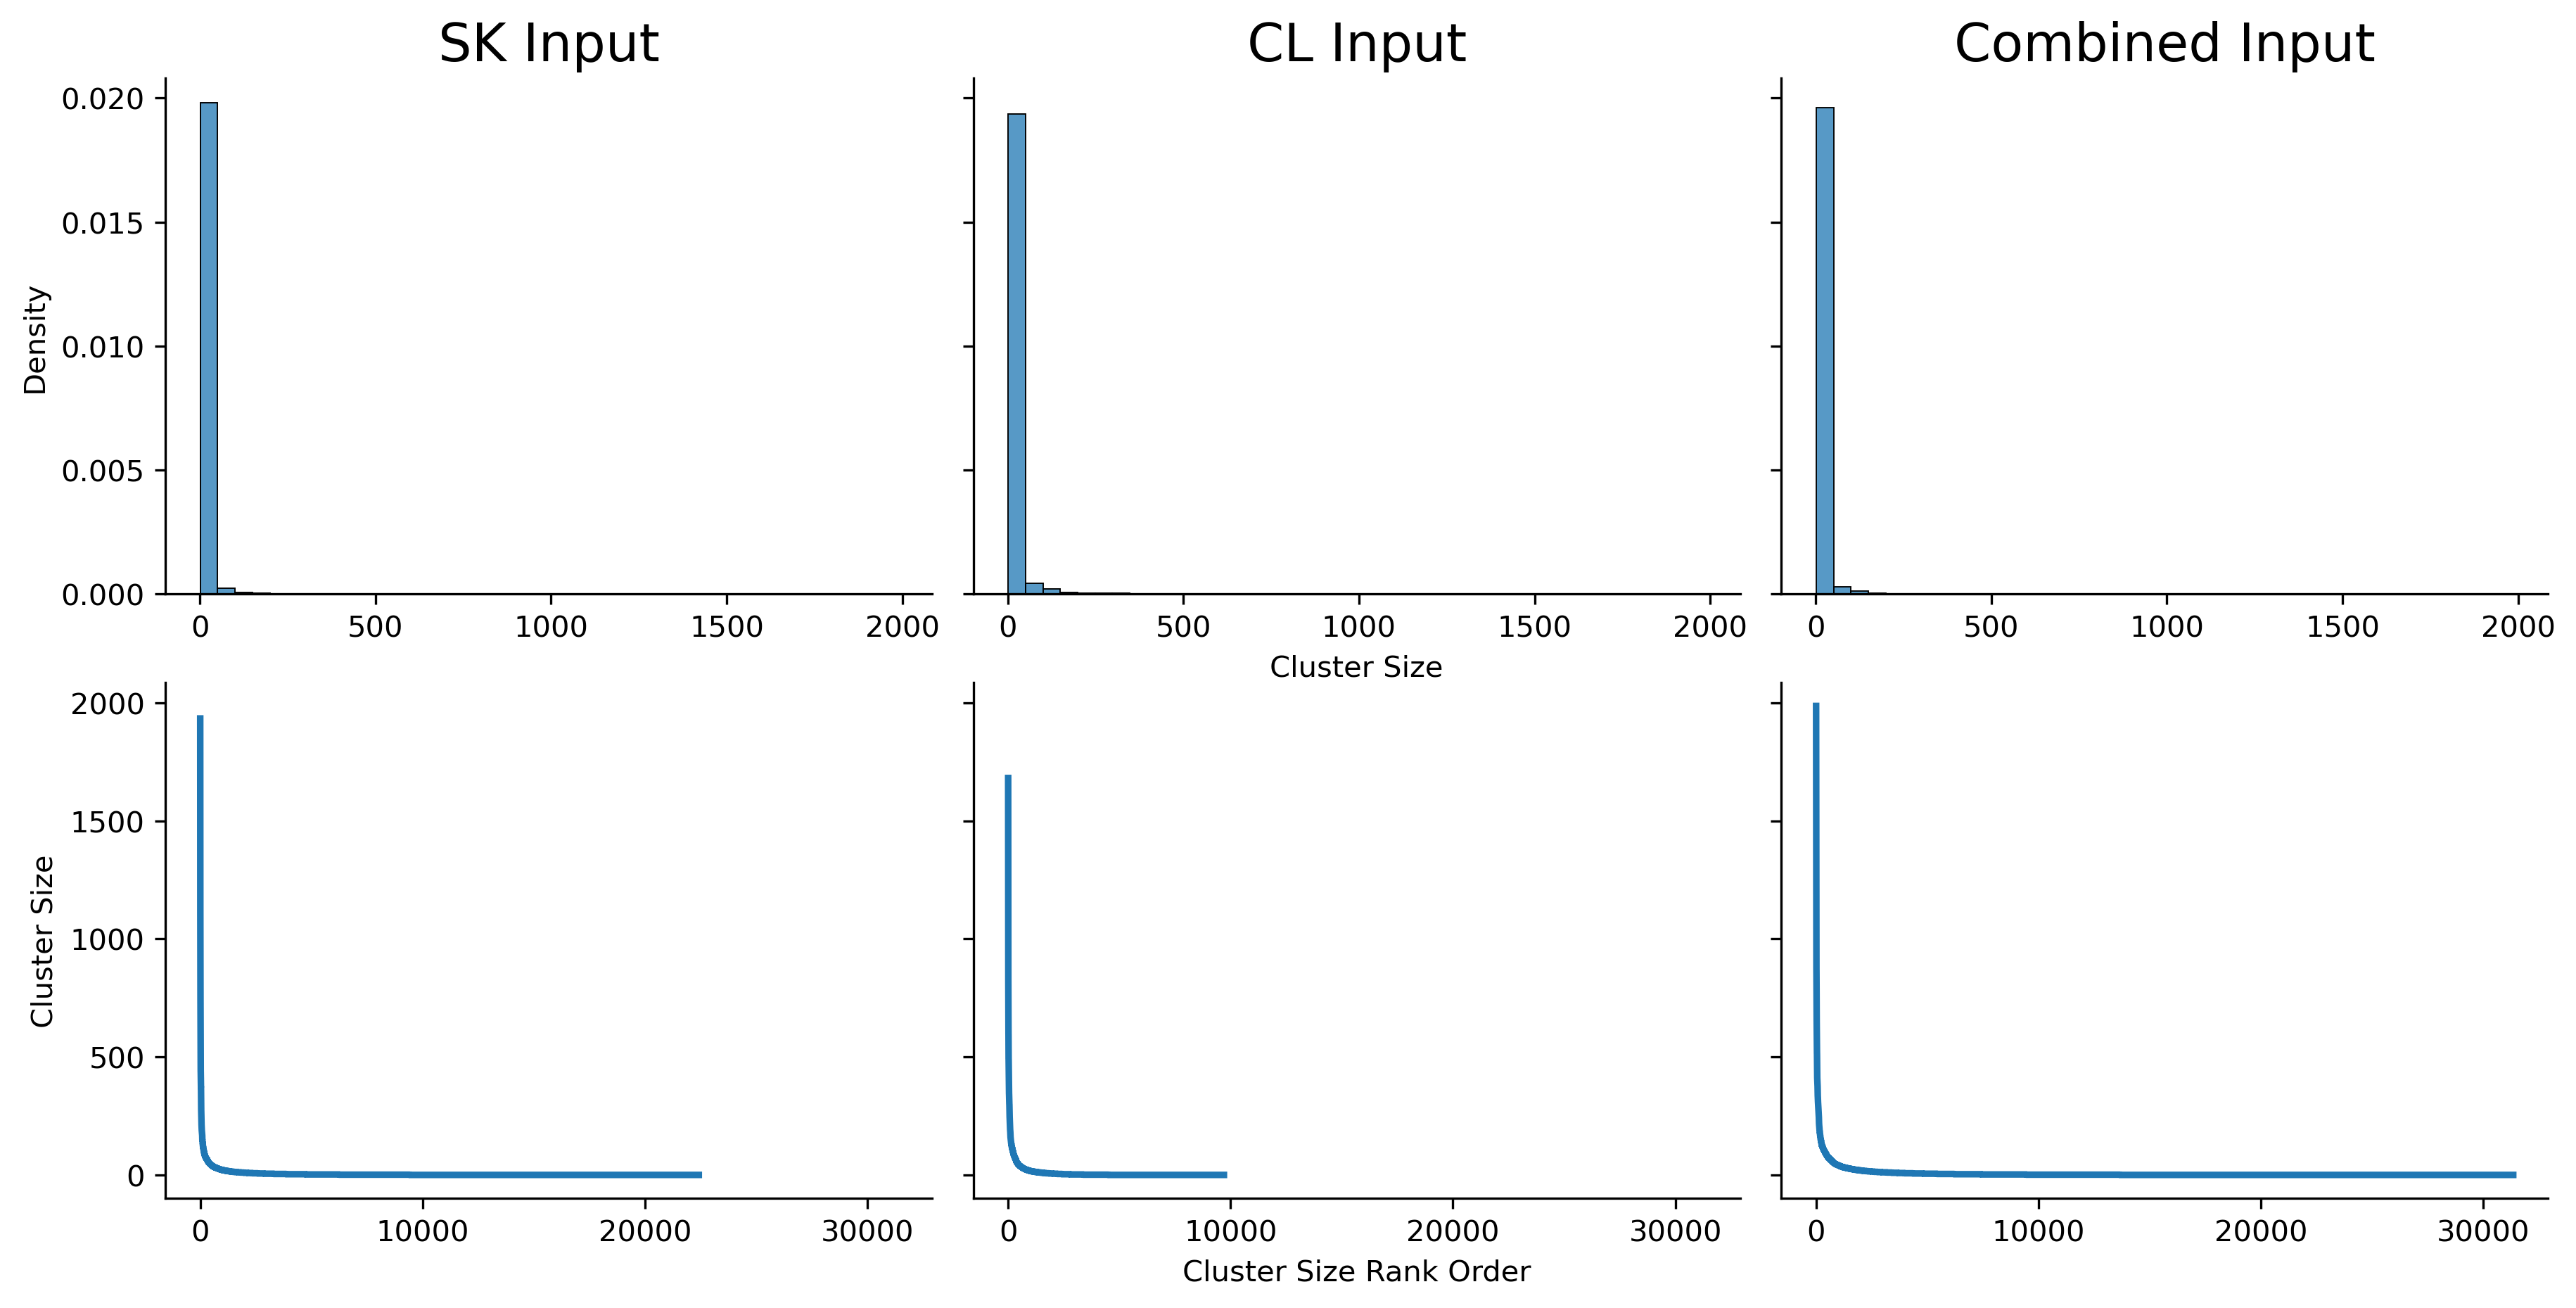

In [53]:
fig, axs = plt.subplots(2, 3, figsize=(12, 6), sharex='row', sharey='row', dpi = 300)
sns.set_context('talk')
# Plot histograms
sns.histplot(SK_clusters[0].value_counts(), binwidth=50, ax=axs[0, 0], stat = 'density')
sns.histplot(CL_clusters[0].value_counts(), binwidth=50, ax=axs[0, 1], stat = 'density')
sns.histplot(CL_SK_clusters[0].value_counts(), binwidth=50, ax=axs[0, 2], stat = 'density')

# Set titles for histograms
axs[0, 0].set_title('SK Input')
axs[0, 1].set_title('CL Input')
axs[0, 2].set_title('Combined Input')

# Plot cluster size rank order
plot_cluster_size(SK_clusters, axs[1, 0])
plot_cluster_size(CL_clusters, axs[1, 1])
plot_cluster_size(CL_SK_clusters, axs[1, 2])

# Remove redundant labels
for ax in axs.flat:
    ax.set_xlabel("")
    ax.set_ylabel("")

# Add shared labels
axs[0,1].set_xlabel("Cluster Size")
axs[0,0].set_ylabel("Density")
axs[1, 1].set_xlabel("Cluster Size Rank Order", y=-0.05)
axs[1,0].set_ylabel("Cluster Size")
#fig.supylabel("Cluster Size")

sns.despine()
plt.tight_layout(pad = 0)

# hide

In [8]:
seqs = protfasta.read_fasta("../output/interpro_uniprot_evid_1_2.fasta")
seqs = pd.DataFrame({"id" : seqs.keys(), "seq" : seqs.values()})
seqs["uniprotID"] = seqs["id"].str.split("|").str[1]
seqs = pd.merge(seqs, clusters, on = "uniprotID")
seqs

,id,seq,uniprotID,cluster_centroid
0,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,A0A0B4K6B8,A0A023ESS1
1,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,A0A0B4K7A6,A0A023ESS1
2,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...,A0A5S9MMK5,A8XJ98
3,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...,Q4VC44,Q4VC44
4,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,Q86B87,A0A023ESS1
...,...,...,...,...
137431,tr|W8C846|W8C846_CERCA (Mediterranean fruit fl...,MNNITRLLANCTLNTTRCHLKYNAAALTAAIQLRGKCKVVVKPAPG...,W8C846,A0A0P4VQK3
137432,tr|W8CA25|W8CA25_CERCA (Mediterranean fruit fl...,MAGRPRRQAATRTAQIIEISDSEDDNSVSKNKRRRRDSSFSPPPTK...,W8CA25,Q9N4L5
137433,tr|W8QUS6|W8QUS6_MIMNO Cold shock domain prote...,MSDSEKQPEEKEEPKKNVIATKVTGTVKWFNVKSGYGFINRDDTKE...,W8QUS6,W8QUS6
137434,tr|X5CQH7|X5CQH7_9EUKA 30S plastidal ribosomal...,MSSARPLVLIASLLGASEALQSCHTRLVSSRVAATPRAAWALTMCD...,X5CQH7,X5CQH7


In [ ]:
cluster_counts = seqs["cluster_centroid"].value_counts()
cluster_counts

In [ ]:
import seaborn as sns
sns.lineplot(seqs["cluster_centroid"].value_counts())

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):

KeyboardInterrupt



Error in callback <function _draw_all_if_interactive at 0x14f25c64f100> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 